## **EDA** (Explanatory Data Analysis) and **Preprocessing**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import nltk
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

nltk.download('stopwords')
from nltk.corpus import stopwords

df = pd.read_csv("../reviews.csv")
df['review_len'] = df['review_text'].str.len()

print(f"Total reviews: {len(df)}")
print(df['review_len'].describe())



In [ ]:
# reprocessing function (reused throughout)
stop_words = set(stopwords.words('english'))
stop_words -= {"not", "no", "nor", "never"} # keep negations

def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    return [w for w in text.split() if w not in stop_words]

## Rating Distribution

        Count  Percentage
rating                   
1        1582   25.475040
2         467    7.520129
3         508    8.180354
4         632   10.177134
5        3021   48.647343


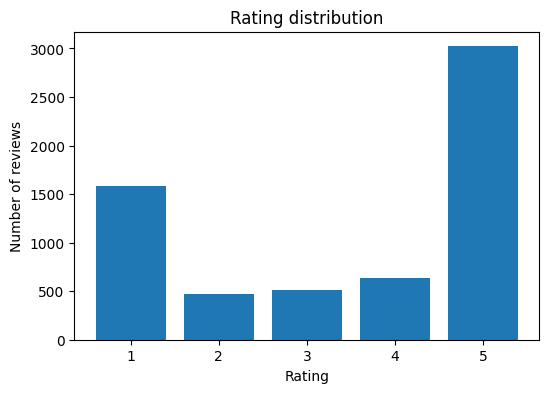

In [48]:
# Rating distribution
rating_stats = pd.DataFrame({
    'Count':      df['rating'].value_counts().sort_index(),
    'Percentage': df['rating'].value_counts(normalize=True).sort_index() * 100
})
print(rating_stats)

plt.figure(figsize=(6, 4))
plt.bar(rating_stats.index, rating_stats['Count'])
plt.xlabel("Rating")
plt.ylabel("Number of reviews")
plt.title("Rating distribution")
plt.show()

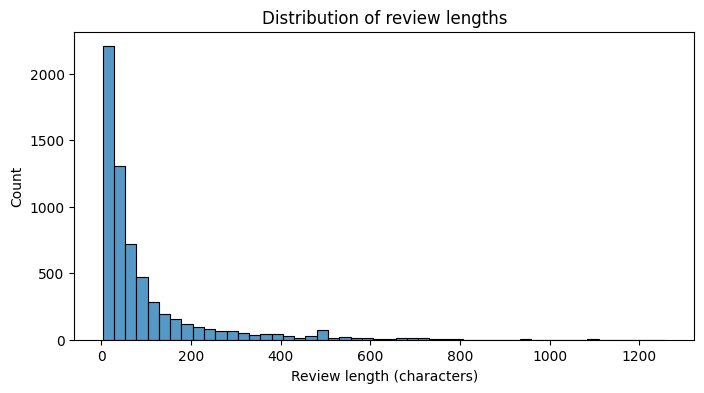

In [49]:
# ── Cell 4: Review length distribution ──────────────────────────────────────
plt.figure(figsize=(8, 4))
sns.histplot(df['review_len'], bins=50)
plt.xlabel("Review length (characters)")
plt.title("Distribution of review lengths")
plt.show()

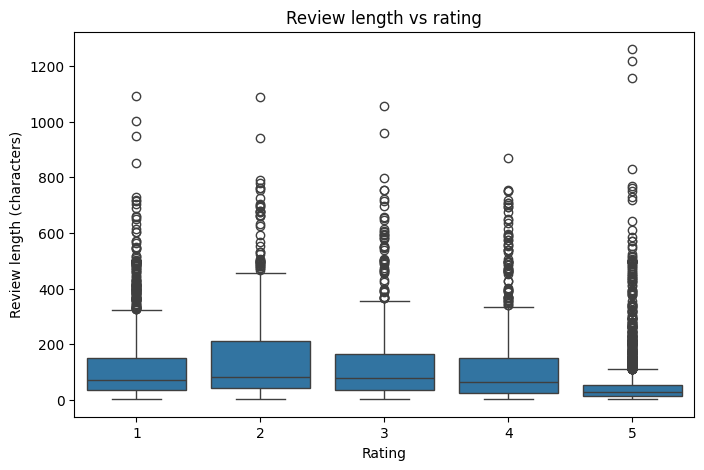

In [50]:
# ── Cell 5: Review length vs rating (boxplot) ───────────────────────────────
plt.figure(figsize=(8, 5))
sns.boxplot(x='rating', y='review_len', data=df)
plt.xlabel("Rating")
plt.ylabel("Review length (characters)")
plt.title("Review length vs rating")
plt.show()

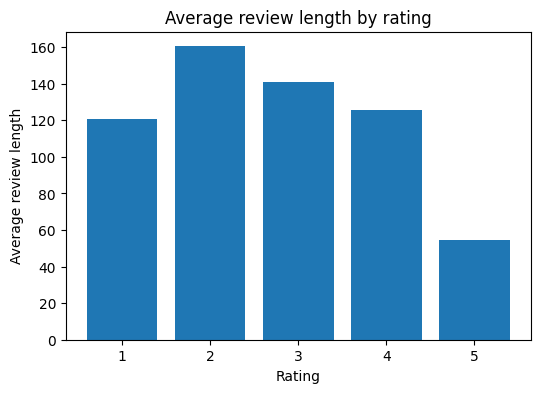

In [51]:
# ── Cell 6: Average review length per rating ────────────────────────────────
avg_length = df.groupby('rating')['review_len'].mean()

plt.figure(figsize=(6, 4))
plt.bar(avg_length.index, avg_length.values)
plt.xlabel("Rating")
plt.ylabel("Average review length")
plt.title("Average review length by rating")
plt.show()

In [52]:
# ── Cell 7: Sentiment label column ──────────────────────────────────────────
def sentiment_label(r):
    if r <= 2:   return "negative"
    elif r == 3: return "neutral"
    else:        return "positive"

df['sentiment'] = df['rating'].apply(sentiment_label)
print(df['sentiment'].value_counts())

positive_reviews = df[df['rating'] >= 4]
negative_reviews = df[df['rating'] <= 2]

sentiment
positive    3653
negative    2049
neutral      508
Name: count, dtype: int64


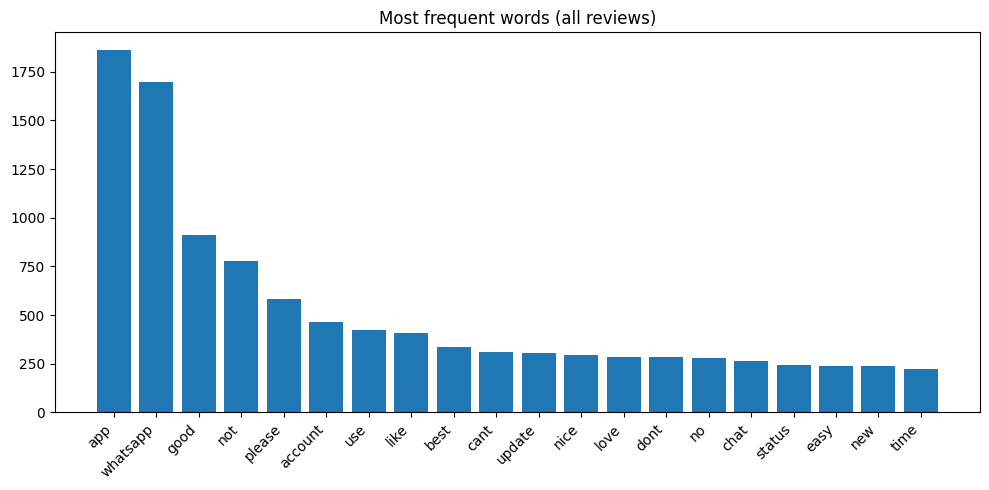

In [54]:
# ── Cell 8: Most frequent words (cleaned, all reviews) ──────────────────────
all_tokens = []
for review in df['review_text']:
    all_tokens.extend(preprocess(review))

common_words = Counter(all_tokens).most_common(20)
words, counts = zip(*common_words)

plt.figure(figsize=(10, 5))
plt.bar(words, counts)
plt.xticks(rotation=45, ha='right')
plt.title("Most frequent words (all reviews)")
plt.tight_layout()
plt.show()

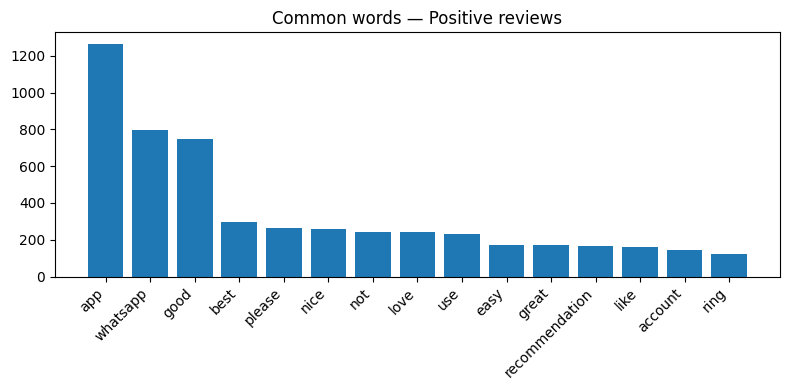

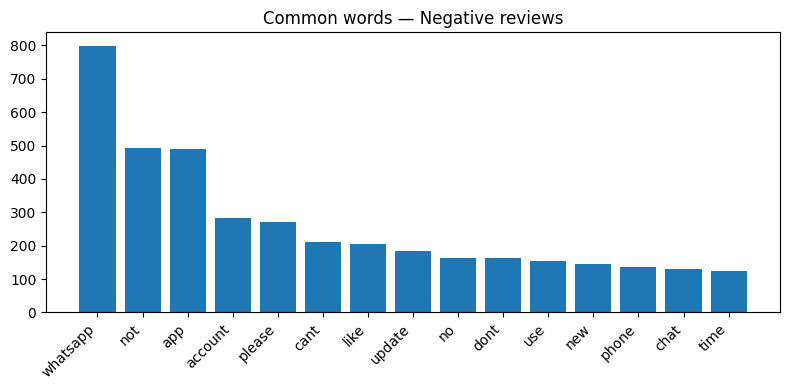

In [55]:
# ── Cell 9: Word frequency — positive vs negative ───────────────────────────
pos_tokens, neg_tokens = [], []

for review in positive_reviews['review_text']:
    pos_tokens.extend(preprocess(review))

for review in negative_reviews['review_text']:
    neg_tokens.extend(preprocess(review))

for tokens, title in [(pos_tokens, "Positive reviews"), (neg_tokens, "Negative reviews")]:
    words, counts = zip(*Counter(tokens).most_common(15))
    plt.figure(figsize=(8, 4))
    plt.bar(words, counts)
    plt.xticks(rotation=45, ha='right')
    plt.title(f"Common words — {title}")
    plt.tight_layout()
    plt.show()

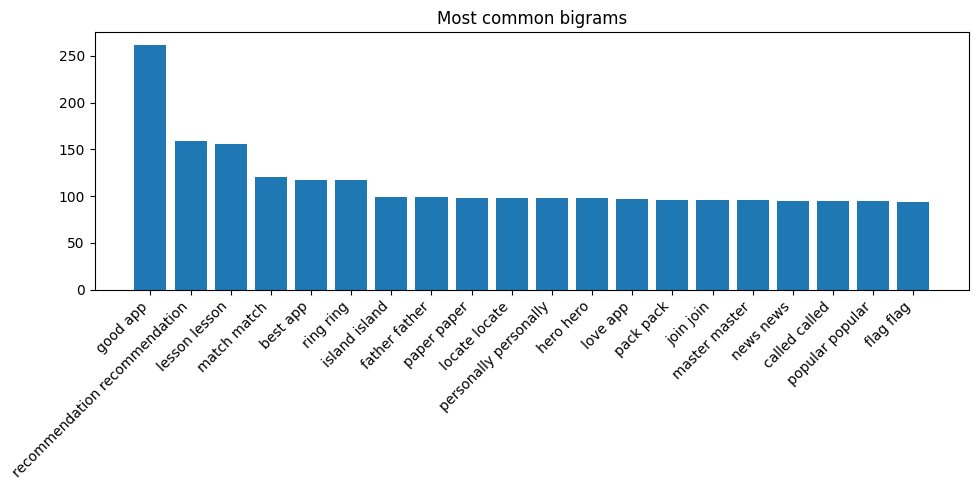

In [11]:
# ── Cell 10: Bigram analysis ─────────────────────────────────────────────────
vectorizer = CountVectorizer(stop_words='english', ngram_range=(2, 2), max_features=20)
X = vectorizer.fit_transform(df['review_text'])
sums = X.sum(axis=0)

bigrams = sorted(
    [(word, sums[0, idx]) for word, idx in vectorizer.vocabulary_.items()],
    key=lambda x: x[1], reverse=True
)
words, counts = zip(*bigrams)

plt.figure(figsize=(10, 5))
plt.bar(words, counts)
plt.xticks(rotation=45, ha='right')
plt.title("Most common bigrams")
plt.tight_layout()
plt.show()

In [ ]:
# Check a few raw reviews for duplicated words
print(df['review_text'].sample(10).tolist())

# Check if any reviews literally contain repeated words
df['has_duplicates'] = df['review_text'].apply(
    lambda x: any(
        w1 == w2 for w1, w2 in zip(x.split(), x.split()[1:])
    )
)
print(f"Reviews with consecutive duplicate words: {df['has_duplicates'].sum()}")
print(df[df['has_duplicates']]['review_text'].head(10))

["What's app is a best app and use full", 'tD4UZtTNK1sRiv3bupSH0zkjtlXXt89TuQsOSQ3mKCHHIP5edW203PZCwwgWte24hhSl4nmDzZBhWGuP8tA', 'very helpful and privacy', 'Very good application', 'I have facing official WhatsApp app issue but i install WhatsApp from Google play store my phone android version 5.0', 'good app', 'The app is very nice and can be used on any device', "it's a nice app by the way easier to operate", 'good experience', 'love this app!']
Reviews with consecutive duplicate words: 249
6      learning learning learning learning learning l...
36     truly truly truly truly truly truly truly trul...
67     percentage percentage percentage percentage pe...
86     I will prefer this app it helps me a lot but I...
94     expansion expansion expansion expansion expans...
125    sample sample sample sample sample sample samp...
135    Okkk good 👍👍👍 👍👍👍 nice 👍👍👍👍 simple and describ...
159                                  It's very very Good
162    its a perfect application But please j

## Data Quality Findings

In [ ]:

# Detect Gibberish (random character strings)
def is_gibberish(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return True
    words = text.split()
    long_token  = any(len(w) > 30 for w in words)
    alnum_ratio = sum(c.isalpha() for c in text) / max(len(text), 1)
    return long_token or alnum_ratio < 0.5

df['is_gibberish'] = df['review_text'].apply(is_gibberish)
print(f"Gibberish reviews:          {df['is_gibberish'].sum()}")
print(df[df['is_gibberish']]['review_text'].head(100).tolist())

Gibberish reviews:          360
['AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA', 'uVlIUP6rZOwbnKA9nUZiWqxC61ia2hHBs2L52NyTHS4nLs', 'aHU4DCtH2mD9rhBxdZwXPAkfhASrXQTvktLUq3hSNkcd0EMIQVfZqEE8zL4ORd45u4k7uOiOXMxnyY0tnN8lBQBSMh4gh', '5EDeqSdCqcmKFz3ewUgZkUKWdc72plozQCTGVGO4mcz09EBSCR6og4Am0vyOsAlcudWgc6CIzX027Y66hc38lJ3lE', '5555555555555555555555555555555555555', 'NX7NnGZDykMM2yrHaKoalnjOgY9UHjIsYeUeqZ5SLGk7IIN7ZTp8IybZod5m78Ngz0rI3Cw9JZZwTa', 'qqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqq', 'iiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiii', '3XxinZKBCmuwNNlpPA31h1dsoIfUFHjIZIZjOtxgG2GByXelgMlUKSSWMVTtkGiZUW0Q5opcEVvfGUj', 'GGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG', '6666666666666666666666666666666666666666666666666', 'ZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZZ', 'dfxnIyiIFsLHymhItDPtY1UgAWPkfG4Uj3wixBWCQ6zLhmYSpK1RxIiQJ7TEGU', '4GRsTYQvesb7vFtHECr3ICnD7L3tZlBdgRxh5c5PVTkNG0Rzj41jS97VN1wGKzKFC3NKjWDj11

In [ ]:
# Spam repetition
def is_spam_repetition(text):
    if not isinstance(text, str):
        return False
    words = text.lower().split()
    if len(words) < 3:
        return False
    most_common_count = Counter(words).most_common(1)[0][1]
    return (most_common_count / len(words)) > 0.5

df['is_spam_repetition'] = df['review_text'].apply(is_spam_repetition)
print(f"Spam repetition reviews:    {df['is_spam_repetition'].sum()}")
print(df[df['is_spam_repetition']]['review_text'].head(100).tolist())

Spam repetition reviews:    182
['learning learning learning learning learning learning learning learning learning learning learning learning learning learning learning learning learning learning learning learning learning learning learning learning learning learning learning learning learning learning learning learning learning learning learning learning learning learning learning learning learning ', 'truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly truly ', 'percentage percentage percentage percentage percentage percentage percentage percentage per

In [32]:
def is_non_english(text):
    if not isinstance(text, str):
        return False
    if len(text.strip()) < 8:
        return False
    # Strip BOTH emojis and non-Latin script before measuring
    stripped = re.sub(r'[^\u0000-\u024F]', '', text).strip()
    # Also strip the emojis from original before comparing
    original_no_emoji = re.sub(r'[^\u0000-\u024F\s]', '', text).strip()
    
    ratio = len(stripped) / max(len(original_no_emoji), 1)
    return ratio < 0.7

df['is_non_english'] = df['review_text'].apply(is_non_english)
print(f"Non-English: {df['is_non_english'].sum()}")
print(df[df['is_non_english']]['review_text'].head(10).tolist())

Non-English: 0
[]


In [ ]:
Emoji spam
def is_emoji_spam(text):
    if not isinstance(text, str):
        return False
    # Count emoji characters (anything above basic Latin/extended Latin)
    emoji_count = len(re.findall(r'[^\x00-\u024F]', text))
    total_chars = max(len(text.strip()), 1)
    # If emojis make up more than 80% of the review it's emoji spam
    return (emoji_count / total_chars) > 0.8

df['is_emoji_spam'] = df['review_text'].apply(is_emoji_spam)
print(f"Emoji spam reviews:         {df['is_emoji_spam'].sum()}")
print(df[df['is_emoji_spam']]['review_text'].head(5).tolist())

Emoji spam reviews:         0
[]


### Data cleaning summary

In [57]:

df['is_bad'] = (
    df['is_gibberish'] |
    df['is_spam_repetition'] |
    df['is_non_english'] |
    df['is_emoji_spam']
)

print("=" * 40)
print(f"Total reviews:              {len(df)}")
print(f"Gibberish:                  {df['is_gibberish'].sum()}")
print(f"Spam repetition:            {df['is_spam_repetition'].sum()}")
print(f"Non-English:                {df['is_non_english'].sum()}")
print(f"Emoji spam:                 {df['is_emoji_spam'].sum()}")
print(f"Total flagged:              {df['is_bad'].sum()} ({df['is_bad'].mean()*100:.1f}%)")
print(f"Clean reviews remaining:    {(~df['is_bad']).sum()}")
print("=" * 40)

Total reviews:              6210
Gibberish:                  360
Spam repetition:            182
Non-English:                0
Emoji spam:                 16
Total flagged:              554 (8.9%)
Clean reviews remaining:    5656


# Cleaning and Preprocessing


In [ ]:
# ── Remove bad rows ──────────────────────────────────────────────────────
original_len = len(df)
df_clean = df[~df['is_bad']].copy().reset_index(drop=True)

print(f"Removed:   {original_len - len(df_clean)} reviews")
print(f"Remaining: {len(df_clean)} reviews")

Removed:   542 reviews
Remaining: 5668 reviews


In [ ]:
# Shared clean_text function ───────────────────────────────────────────
# This is the ONLY preprocessing all four models share.
# Each model then applies its own vectorization on top of this.
#
# Stopwords: we keep negations AND degree words (very, too, most)
# because these carry sentiment signal for all model types.

stop_words = set(stopwords.words('english'))

sentiment_keepers = {
    'not', 'no', 'nor', 'never', 'neither', 'nobody', 'nothing', 'nowhere',
    'very', 'too', 'most', 'more', 'less', 'least', 'few',
    'but', 'however', 'although', 'only', 'just'
}
stop_words = stop_words - sentiment_keepers

# Also remove domain-specific words that carry no sentiment signal
domain_noise = {'app', 'whatsapp', 'apps'}
stop_words = stop_words | domain_noise

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)       # remove URLs
    text = re.sub(r'\S+@\S+', '', text)              # remove emails
    text = re.sub(r'[^a-z\s]', '', text)             # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()         # normalise whitespace
    text = ' '.join(
        w for w in text.split() if w not in stop_words
    )
    return text

df_clean['clean_text'] = df_clean['review_text'].apply(clean_text)

# Drop rows that are empty after cleaning
before = len(df_clean)
df_clean = df_clean[df_clean['clean_text'].str.len() > 0].reset_index(drop=True)
print(f"Dropped {before - len(df_clean)} empty reviews after cleaning")

Dropped 11 empty reviews after cleaning


In [44]:
# ── 4.3 Sentiment label ───────────────────────────────────────────────────────
def sentiment_label(r):
    if r <= 2:   return "negative"
    elif r == 3: return "neutral"
    else:        return "positive"

df_clean['sentiment'] = df_clean['rating'].apply(sentiment_label)
print(df_clean['sentiment'].value_counts())

sentiment
positive    3407
negative    1844
neutral      406
Name: count, dtype: int64


In [42]:
# ── 4.4 Train/test split — shared across ALL models ──────────────────────────
# We save the indices so every model notebook uses identical splits.
# This is essential for fair comparison of evaluation metrics.

from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(
    df_clean.index,
    test_size=0.2,
    random_state=42,
    stratify=df_clean['sentiment']   # preserve class balance
)

df_train = df_clean.loc[train_idx].reset_index(drop=True)
df_test  = df_clean.loc[test_idx].reset_index(drop=True)

print(f"Train: {len(df_train)} reviews")
print(f"Test:  {len(df_test)} reviews")
print("\nTrain sentiment distribution:")
print(df_train['sentiment'].value_counts(normalize=True).round(3))
print("\nTest sentiment distribution:")
print(df_test['sentiment'].value_counts(normalize=True).round(3))

Train: 4525 reviews
Test:  1132 reviews

Train sentiment distribution:
sentiment
positive    0.602
negative    0.326
neutral     0.072
Name: proportion, dtype: float64

Test sentiment distribution:
sentiment
positive    0.602
negative    0.326
neutral     0.072
Name: proportion, dtype: float64


In [45]:
# ── 4.5 Save outputs ─────────────────────────────────────────────────────────
df_clean.to_csv("reviews_clean.csv", index=False)
df_train.to_csv("reviews_train.csv", index=False)
df_test.to_csv("reviews_test.csv",  index=False)

print("Saved:")
print(f"  reviews_clean.csv  — full cleaned dataset ({len(df_clean)} rows)")
print(f"  reviews_train.csv  — training split ({len(df_train)} rows)")
print(f"  reviews_test.csv   — test split ({len(df_test)} rows)")

Saved:
  reviews_clean.csv  — full cleaned dataset (5657 rows)
  reviews_train.csv  — training split (4525 rows)
  reviews_test.csv   — test split (1132 rows)
